In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import solve_ivp
import pandas as pd

# ── Parámetros del problema ──────────────
alpha = 0.2       # Constante de difusión térmica
L     = 1.0       # Ancho de la pared [m]
N     = 10        # Número de divisiones espaciales
dx    = L / N     # Paso espacial
T0    = 100.0     # Temperatura inicial [°C]

x = np.linspace(0, L, N+1)

print(f"α  = {alpha}")
print(f"l  = {L} m")
print(f"N  = {N}")
print(f"Δx = {dx}")
print(f"Criterio estabilidad → α²Δt/Δx² = {alpha**2 * 0.05 / dx**2:.3f} ≤ 0.5 ✔")

α  = 0.2
l  = 1.0 m
N  = 10
Δx = 0.1
Criterio estabilidad → α²Δt/Δx² = 0.200 ≤ 0.5 ✔


In [13]:
def derivs(t, T):
    dTdt = np.zeros_like(T)
    a2   = alpha**2
    dx2  = dx**2

    # Frontera fija x=0
    dTdt[0] = 0.0

    # Puntos interiores
    for i in range(1, N):
        dTdt[i] = a2 * (T[i+1] - 2*T[i] + T[i-1]) / dx2

    # Frontera aislada x=l  →  Neumann
    T_der   = (4*T[N] - T[N-1]) / 3.0
    dTdt[N] = a2 * (T_der - 2*T[N] + T[N-1]) / dx2

    return dTdt

In [14]:
def T_analitica(x, t, alpha=alpha, L=L, n_terms=50):
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k  = (2*n + 1) / (2*L) * np.pi
        T += (1/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400/np.pi) * T

## Python

In [48]:
# ── Leer archivo Fortran ─────────────────
# skiprows=1 indica a numpy que ignore la primera fila del archivo
datos = np.loadtxt('CNPY.dat', skiprows=1)

t_py   = datos[:, 0]        # Tiempos
T_py   = datos[:, 1:N+1]    # Temperaturas T1..T10  (N puntos)
T_pyd  = datos[:, N+1]      # Temperatura frontera aislada

print(f"Pasos leídos : {len(t_py)}")
print(f"t inicio     : {t_py[0]}")
print(f"t final      : {t_py[-1]}")
print(f"Shape datos  : {T_py.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


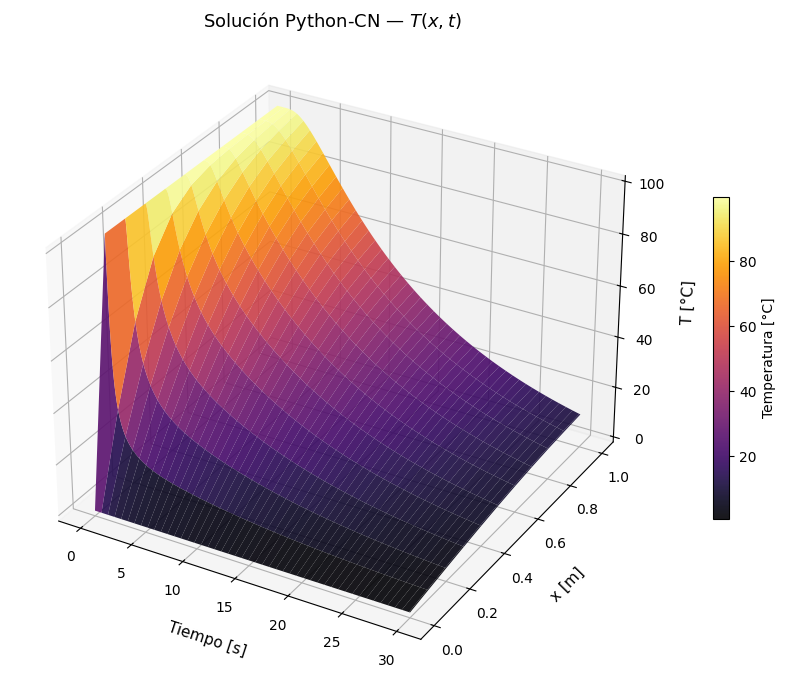

In [62]:
# x completo: 11 puntos de 0.0 a 1.0
x_py = np.linspace(0, L, N + 1)

# Z completo: concatenar T_f (10 cols) + T_fd (1 col) → shape (601, 11)
Z_grid_py = np.column_stack([T_py, T_pyd])

X_grid_py, T_grid_py = np.meshgrid(x_py, t_py)   # ambos 601×11

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_py, X_grid_py, Z_grid_py,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución Python-CN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

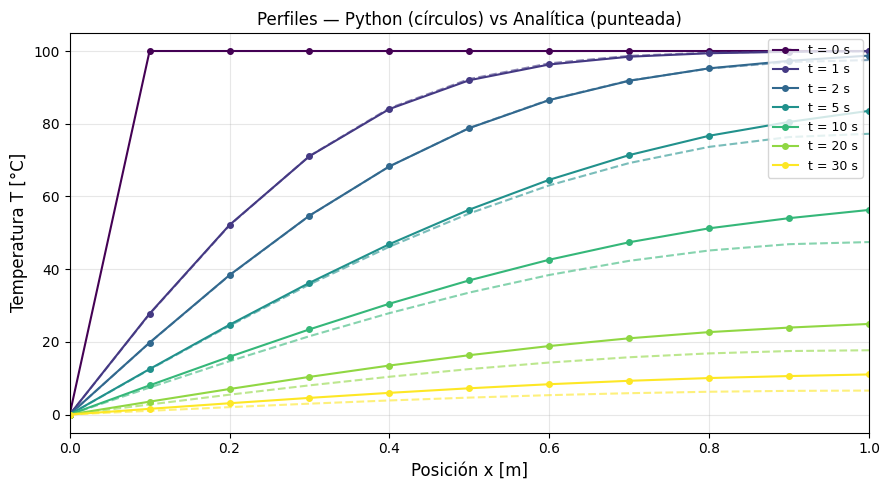

In [63]:
# ── Perfiles de temperatura C++ vs Analítica ─────────────────
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_py - tp))
    T_fila = np.concatenate([T_py[idx], [T_pyd[idx]]])

    ax.plot(x_py, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_py, T_analitica(x_py, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — Python (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

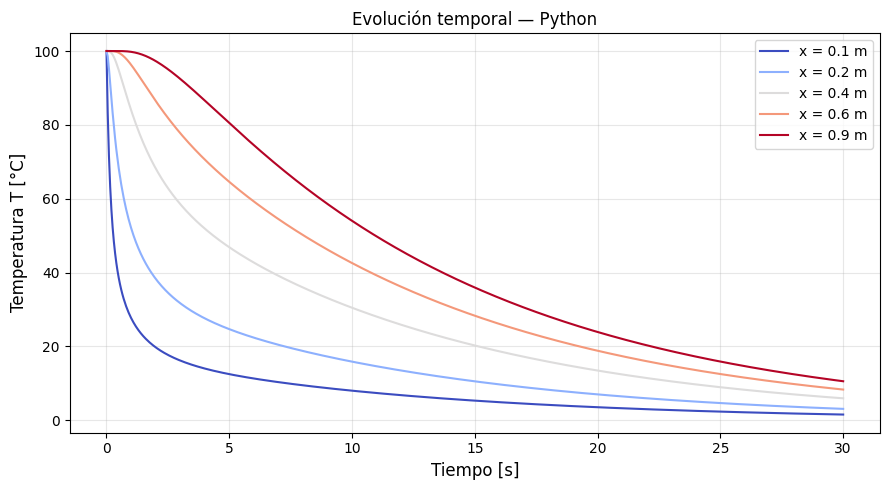

In [64]:
# ── Evolución temporal por punto C++ ─────────────────────────
puntos_cpp = [1, 2, 4, 6, 9]
colores    = cm.coolwarm(np.linspace(0, 1, len(puntos_cpp)))

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_cpp, colores):
    ax.plot(t_py, T_py[:, idx_x], color=color,
            label=f'x = {x_py[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — Python', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

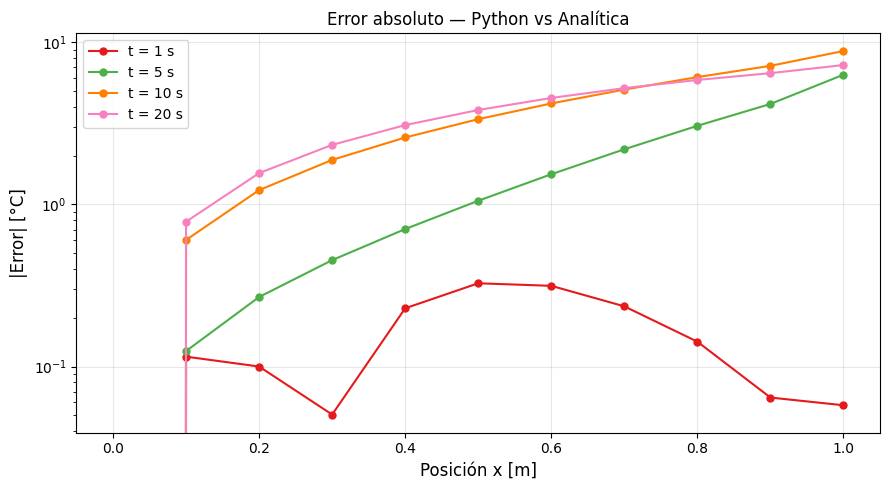

In [65]:
# ── Error absoluto C++ vs Analítica ──────────────────────────
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_py - tp))
    T_fila = np.concatenate([T_py[idx], [T_pyd[idx]]])
    err    = np.abs(T_fila - T_analitica(x_py, tp))

    ax.plot(x_py, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — Python vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fortran

In [83]:
# ── Leer archivo Fortran ─────────────────
datos = np.loadtxt('CNF.dat', skiprows=1)

t_f   = datos[:, 0]        # Tiempos
T_f   = datos[:, 1:N+1]    # Temperaturas T1..T10  (N puntos)
T_fd  = datos[:, N+1]      # Temperatura frontera aislada

print(f"Pasos leídos : {len(t_f)}")
print(f"t inicio     : {t_f[0]}")
print(f"t final      : {t_f[-1]}")
print(f"Shape datos  : {T_f.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


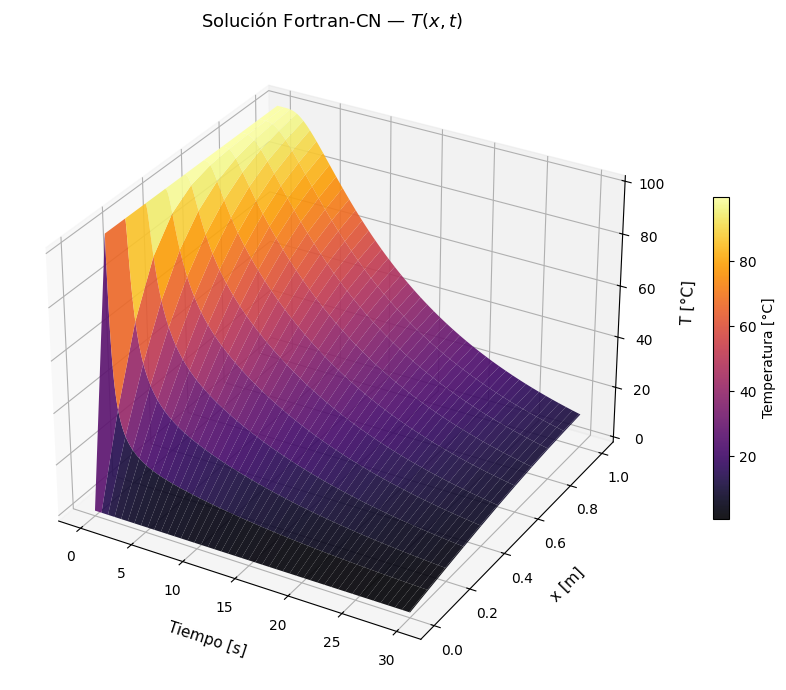

In [84]:
# x completo: 11 puntos de 0.0 a 1.0
x_f = np.linspace(0, L, N + 1)

# Z completo: concatenar T_f (10 cols) + T_fd (1 col) → shape (601, 11)
Z_grid_f = np.column_stack([T_f, T_fd])

X_grid_f, T_grid_f = np.meshgrid(x_f, t_f)   # ambos 601×11

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_f, X_grid_f, Z_grid_f,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución Fortran-CN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

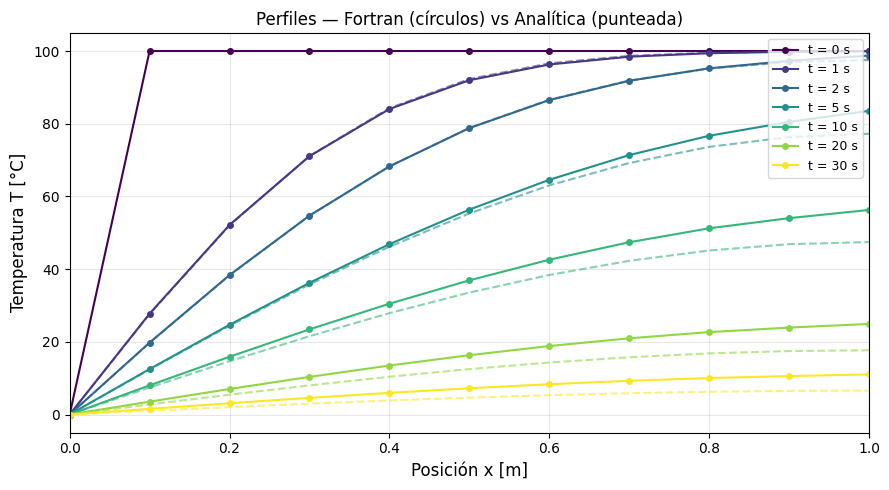

In [85]:
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11

    ax.plot(x_f, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_f, T_analitica(x_f, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — Fortran (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

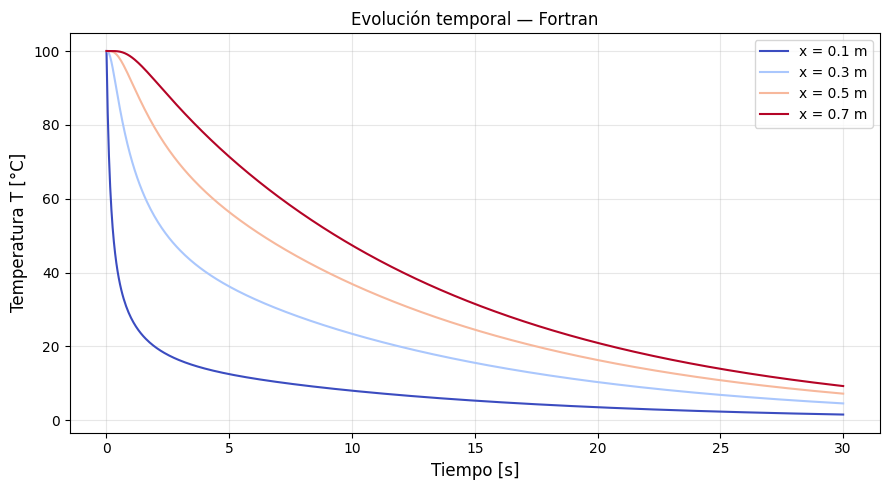

In [86]:
puntos_f = [1, 3, 5, 7]    # índices columnas de T_f
colores  = cm.coolwarm(np.linspace(0, 1, len(puntos_f)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_f, colores):
    ax.plot(t_f, T_f[:, idx_x], color=color,
            label=f'x = {x_f[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — Fortran', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

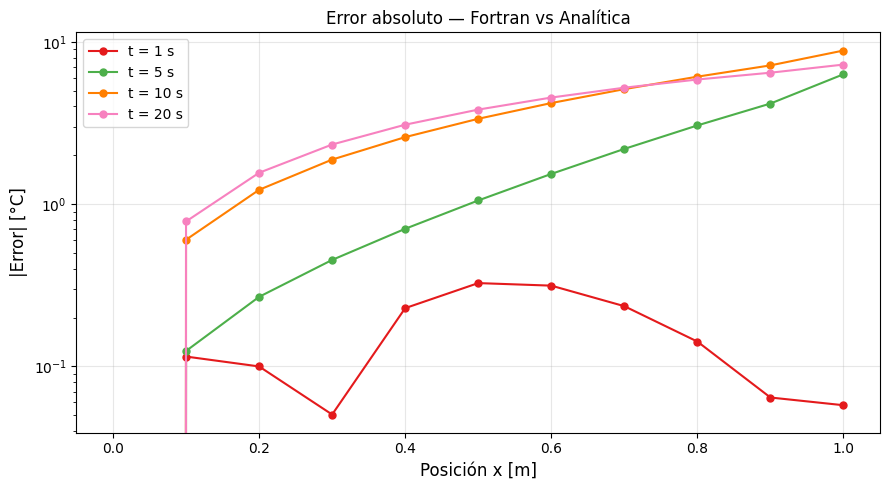

In [87]:
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11
    err    = np.abs(T_fila - T_analitica(x_f, tp))

    ax.plot(x_f, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — Fortran vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
t_tabla = 5.0
idx     = np.argmin(np.abs(t_f - t_tabla))
T_fila  = np.concatenate([[0.0], T_f[idx]])
T_an    = T_analitica(x, t_tabla)

df_f = pd.DataFrame({
    'x [m]'       : np.round(x,                      2),
    'T Fortran'   : np.round(T_fila,                  4),
    'T analítico' : np.round(T_an,                    4),
    '|Error|'     : np.round(np.abs(T_fila - T_an),   6)
})

display(df_f)

,x [m],T Fortran,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,0.0000,12.3869,12.386873
2,0.2,12.5114,24.4248,11.913406
3,0.3,24.6932,35.7830,11.089843
4,0.4,36.2362,46.1647,9.928452
5,0.5,46.8692,55.3176,8.448389
6,0.6,56.3708,63.0401,6.669307
7,0.7,64.5750,69.1806,4.605556
8,0.8,71.3691,73.6327,2.263619
9,0.9,76.6861,76.3286,0.357476


## C++

In [77]:
# ── Leer archivo C++ ─────────────────────────────────────────
datos_cpp = np.loadtxt('CNCPP.dat', skiprows=1)

t_cpp  = datos_cpp[:, 0]
T_cpp  = datos_cpp[:, 1:N+1]
T_cpd  = datos_cpp[:, N+1]

x_cpp = np.linspace(0, L, N + 1)

print(f"Pasos leídos : {len(t_cpp)}")
print(f"t inicio     : {t_cpp[0]}")
print(f"t final      : {t_cpp[-1]}")
print(f"Shape datos  : {T_cpp.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


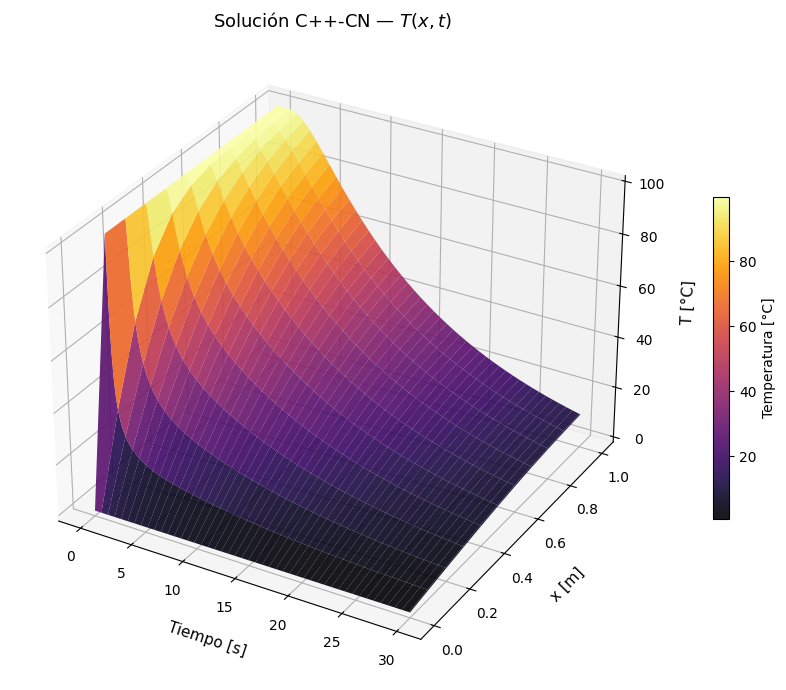

In [78]:
# ── Superficie 3D C++ ────────────────────────────────────────
Z_grid_cpp = np.column_stack([T_cpp, T_cpd])
X_grid_cpp, T_grid_cpp = np.meshgrid(x_cpp, t_cpp)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_cpp, X_grid_cpp, Z_grid_cpp,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución C++-CN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

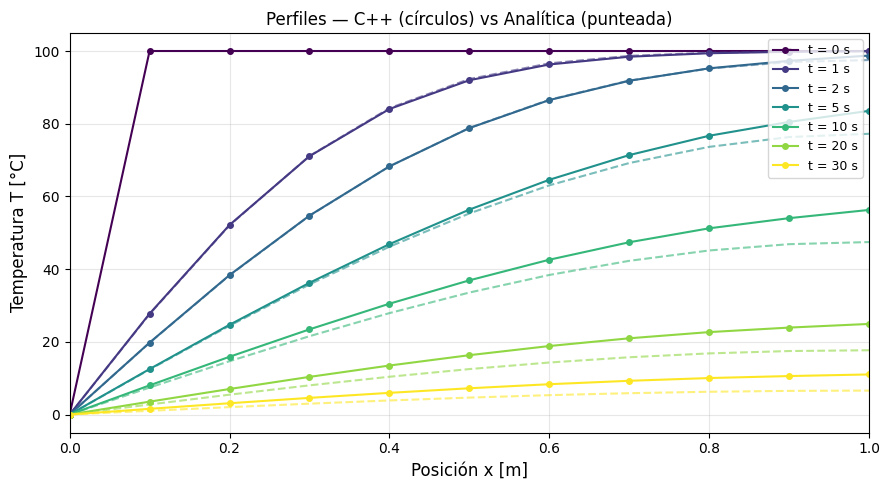

In [79]:
# ── Perfiles de temperatura C++ vs Analítica ─────────────────
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_cpp - tp))
    T_fila = np.concatenate([T_cpp[idx], [T_cpd[idx]]])

    ax.plot(x_cpp, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_cpp, T_analitica(x_cpp, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — C++ (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

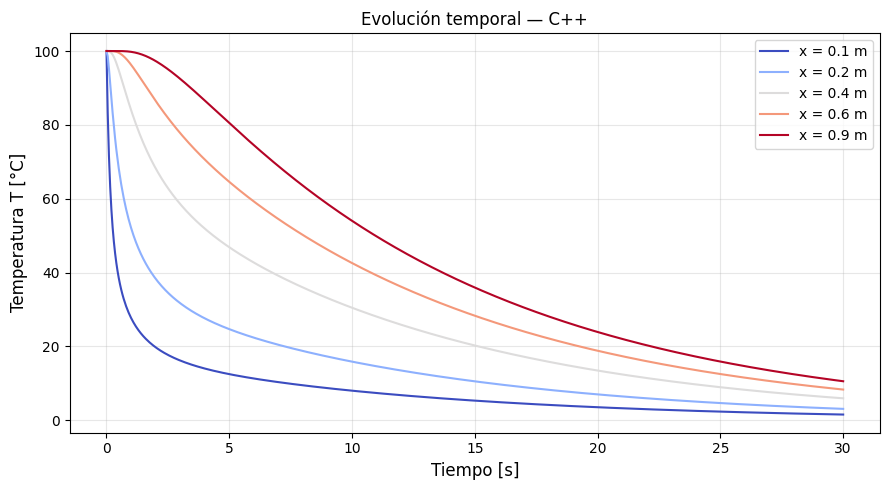

In [80]:
# ── Evolución temporal por punto C++ ─────────────────────────
puntos_cpp = [1, 2, 4, 6, 9]
colores    = cm.coolwarm(np.linspace(0, 1, len(puntos_cpp)))

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_cpp, colores):
    ax.plot(t_cpp, T_cpp[:, idx_x], color=color,
            label=f'x = {x_cpp[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — C++', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

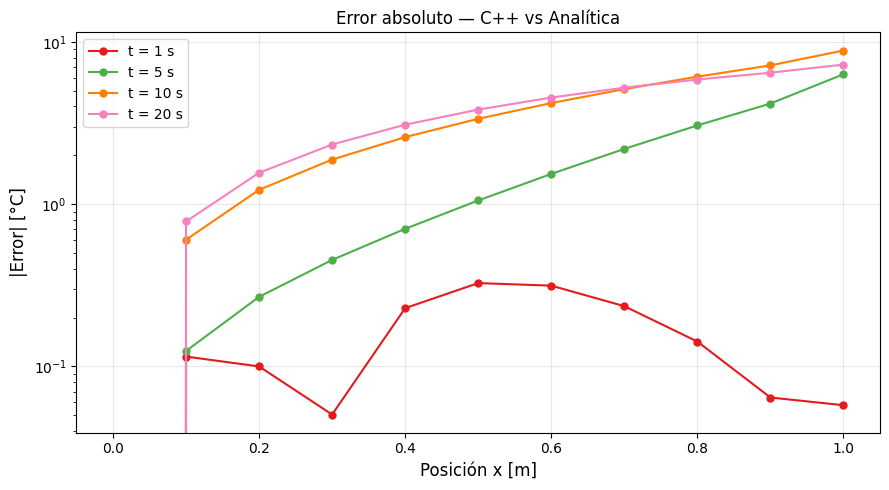

In [81]:
# ── Error absoluto C++ vs Analítica ──────────────────────────
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_cpp - tp))
    T_fila = np.concatenate([T_cpp[idx], [T_cpd[idx]]])
    err    = np.abs(T_fila - T_analitica(x_cpp, tp))

    ax.plot(x_cpp, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — C++ vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
# ── Tabla comparativa C++ en t=5s ────────────────────────────
t_tabla    = 5.0
idx        = np.argmin(np.abs(t_cpp - t_tabla))
T_fila_cpp = np.concatenate([T_cpp[idx], [T_cpd[idx]]])
T_an       = T_analitica(x_cpp, t_tabla)

df_cpp = pd.DataFrame({
    'x [m]'       : np.round(x_cpp,                        2),
    'T C++'        : np.round(T_fila_cpp,                   4),
    'T analítico'  : np.round(T_an,                         4),
    '|Error|'      : np.round(np.abs(T_fila_cpp - T_an),    6)
})

display(df_cpp)

,x [m],T C++,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,12.5114,12.3869,0.124527
2,0.2,24.6932,24.4248,0.268394
3,0.3,36.2362,35.7830,0.453157
4,0.4,46.8692,46.1647,0.704548
5,0.5,56.3708,55.3176,1.053211
6,0.6,64.5750,63.0401,1.534893
7,0.7,71.3691,69.1806,2.188544
8,0.8,76.6861,73.6327,3.053381
9,0.9,80.4934,76.3286,4.164776


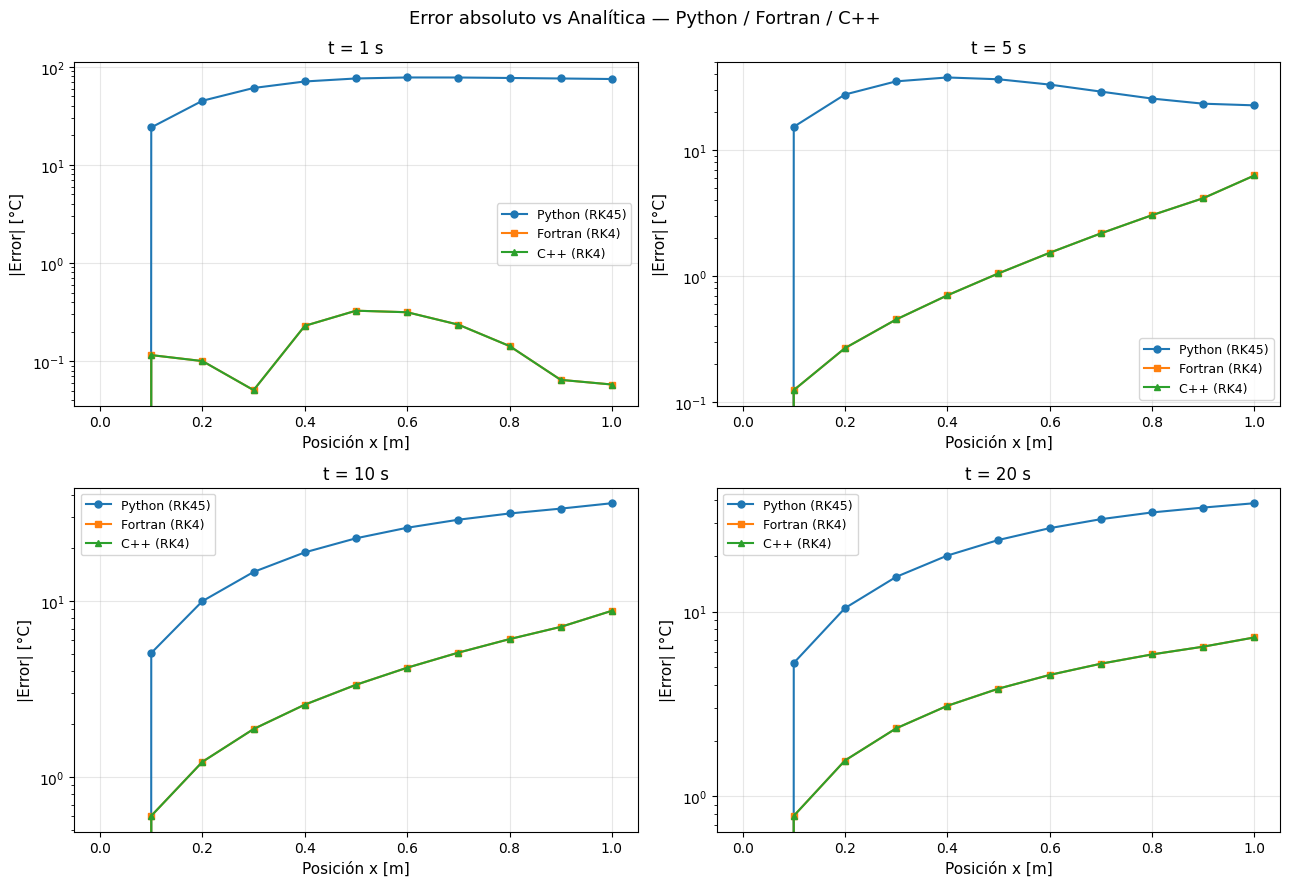

In [95]:
# ── Error absoluto comparativo: Python vs Fortran vs C++ ─────
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

x_f   = np.linspace(0, L, N + 1)
x_cpp = np.linspace(0, L, N + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, tp, color in zip(axes, tiempos_error, colores):
    # ── Python ──────────────────────────────
    idx_py   = np.argmin(np.abs(t_py - tp))
    T_fila_py = np.concatenate([T_py[idx_py], [T_pyd[idx_py]]])
    err_py    = np.abs(T_fila_f - T_analitica(x_f, tp))
    
    # ── Fortran ─────────────────────────────
    idx_f   = np.argmin(np.abs(t_f - tp))
    T_fila_f = np.concatenate([T_f[idx_f], [T_fd[idx_f]]])
    err_f    = np.abs(T_fila_f - T_analitica(x_f, tp))
    
    # ── C++ ─────────────────────────────────
    idx_c    = np.argmin(np.abs(t_cpp - tp))
    T_fila_c = np.concatenate([T_cpp[idx_c], [T_cpd[idx_c]]])
    err_c    = np.abs(T_fila_c - T_analitica(x_cpp, tp))
    
    # ── Graficar ────────────────────────────
    # Nota: Tienes la variable 'color' del ciclo, podrías usarla aquí si quieres
    ax.plot(x,     err_py, '-o',  markersize=5, label='Python (RK45)')
    ax.plot(x_f,   err_f,  '-s',  markersize=5, label='Fortran (RK4)')
    ax.plot(x_cpp, err_c,  '-^',  markersize=5, label='C++ (RK4)')
    
    ax.set_title(f't = {tp} s', fontsize=12)
    ax.set_xlabel('Posición x [m]', fontsize=11)
    ax.set_ylabel('|Error| [°C]',   fontsize=11)
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Configuraciones finales (Fuera del ciclo for) ──
fig.suptitle('Error absoluto vs Analítica — Python / Fortran / C++', fontsize=13)
plt.tight_layout()
plt.show()

,t [s],Error Python,Error Fortran,Error C++
0,1,0.148606,0.148606,0.148606
1,5,1.805034,1.805034,1.805034
2,10,3.731218,3.731218,3.731218
3,20,3.715885,3.715885,3.715885


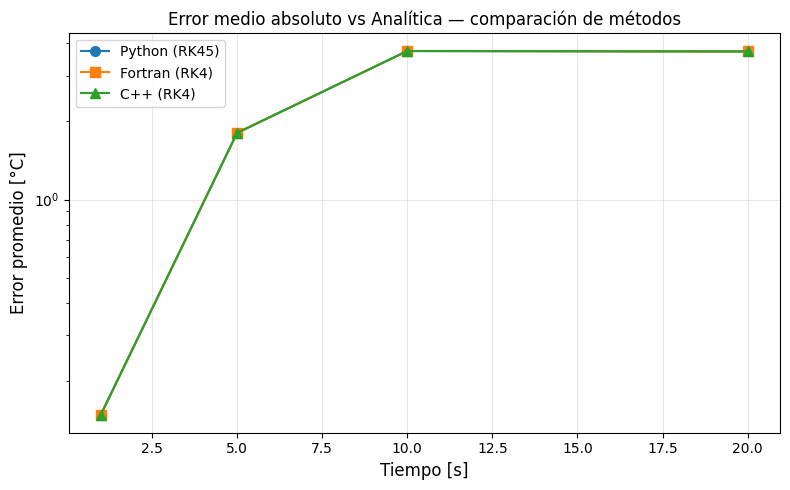

In [97]:
# ── Error promedio comparativo: Python vs Fortran vs C++ ─────
tiempos_error = [1, 5, 10, 20]

err_py_med = []
err_f_med  = []
err_c_med  = []

x_f   = np.linspace(0, L, N + 1)
x_cpp = np.linspace(0, L, N + 1)

for tp in tiempos_error:

    # Python
    idx_py    = np.argmin(np.abs(t_py - tp))
    T_fila_py = np.concatenate([T_py[idx_py], [T_pyd[idx_py]]])
    err_py_med.append(np.mean(np.abs(T_fila_py - T_analitica(x_py, tp))))

    # Fortran
    idx_f    = np.argmin(np.abs(t_f - tp))
    T_fila_f = np.concatenate([T_f[idx_f], [T_fd[idx_f]]])
    err_f_med.append(np.mean(np.abs(T_fila_f - T_analitica(x_f, tp))))

    # C++
    idx_c    = np.argmin(np.abs(t_cpp - tp))
    T_fila_c = np.concatenate([T_cpp[idx_c], [T_cpd[idx_c]]])
    err_c_med.append(np.mean(np.abs(T_fila_c - T_analitica(x_cpp, tp))))

# ── Tabla ────────────────────────────────────────────────────
df_err = pd.DataFrame({
    't [s]'         : tiempos_error,
    'Error Python'  : np.round(err_py_med, 6),
    'Error Fortran' : np.round(err_f_med,  6),
    'Error C++'     : np.round(err_c_med,  6),
})
display(df_err)

# ── Gráfica ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tiempos_error, err_py_med, '-o', markersize=7, label='Python (RK45)')
ax.plot(tiempos_error, err_f_med,  '-s', markersize=7, label='Fortran (RK4)')
ax.plot(tiempos_error, err_c_med,  '-^', markersize=7, label='C++ (RK4)')

ax.set_xlabel('Tiempo [s]',         fontsize=12)
ax.set_ylabel('Error promedio [°C]', fontsize=12)
ax.set_title('Error medio absoluto vs Analítica — comparación de métodos', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

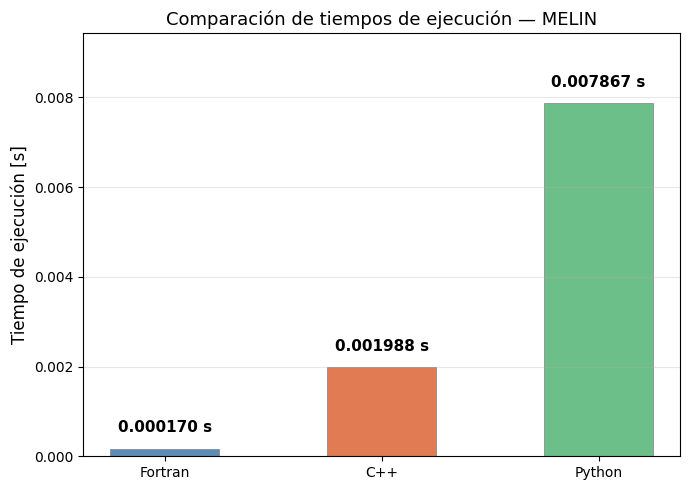

In [98]:
# ── Comparación de tiempos de ejecución ──────────────────────
lenguajes = ['Fortran', 'C++', 'Python']
tiempos   = [0.000170, 0.001988, 0.007867]
colores   = ['#5B8DB8', '#E07B54', '#6DBF8A']

fig, ax = plt.subplots(figsize=(7, 5))

barras = ax.bar(lenguajes, tiempos, color=colores, width=0.5, edgecolor='gray', linewidth=0.5)

# Etiqueta encima de cada barra
for barra, t in zip(barras, tiempos):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.0003,
            f'{t:.6f} s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Tiempo de ejecución [s]', fontsize=12)
ax.set_title('Comparación de tiempos de ejecución — MELIN', fontsize=13)
ax.set_ylim(0, max(tiempos) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

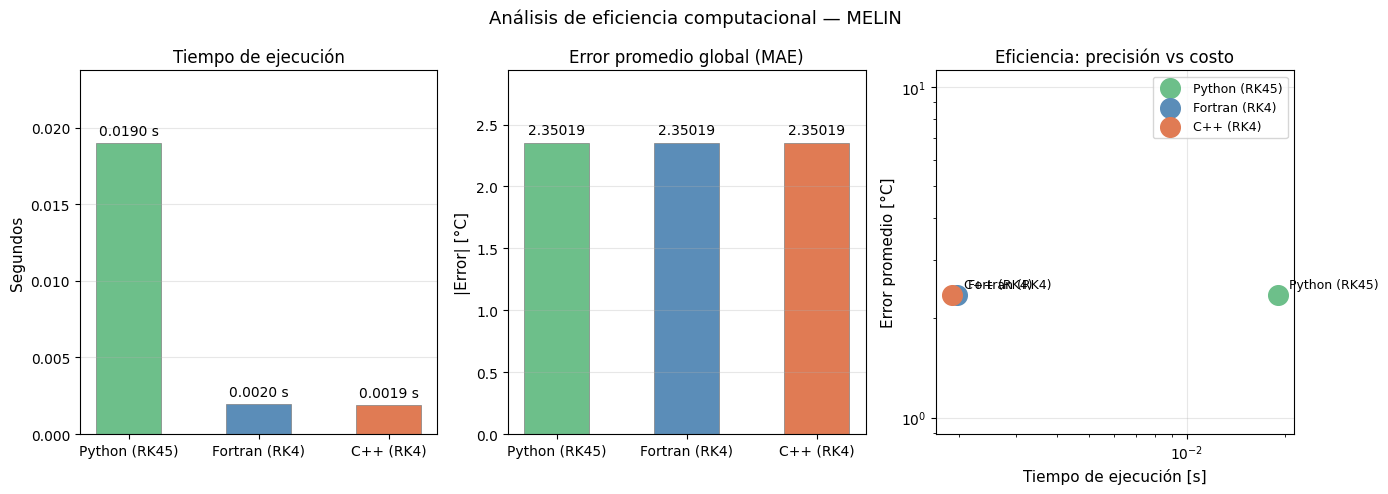

,Método,Tiempo [s],Error MAE [°C],Eficiencia (1/eт)
0,Python (RK45),0.018988,2.350186,22.41
1,Fortran (RK4),0.001969,2.350186,216.10
2,C++ (RK4),0.001910,2.350186,222.77


In [ ]:
# ── Eficiencia: error vs tiempo de ejecución ─────────────────
tiempos_ejec = {
    'Python (RK5)' : 0.018988,
    'Fortran (RK4)' : 0.001969,
    'C++ (RK4)'     : 0.001910,
}

# Error promedio global (promedio sobre todos los tiempos)
err_global_py = np.mean(err_py_med)
err_global_f  = np.mean(err_f_med)
err_global_c  = np.mean(err_c_med)

metodos     = list(tiempos_ejec.keys())
t_ejec      = list(tiempos_ejec.values())
errores     = [err_global_py, err_global_f, err_global_c]
colores_met = ['#6DBF8A', '#5B8DB8', '#E07B54']

# ── Eficiencia = 1 / (error * tiempo) ───────────────────────
# Cuanto mayor, mejor relación precisión/costo
eficiencia = [1 / (e * t) for e, t in zip(errores, t_ejec)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Subgráfica 1: Tiempo de ejecución ───────────────────────
bars1 = axes[0].bar(metodos, t_ejec, color=colores_met,
                    width=0.5, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars1, t_ejec):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.0003,
                 f'{v:.4f} s', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Tiempo de ejecución', fontsize=12)
axes[0].set_ylabel('Segundos', fontsize=11)
axes[0].set_ylim(0, max(t_ejec) * 1.25)
axes[0].grid(axis='y', alpha=0.3)

# ── Subgráfica 2: Error promedio global ──────────────────────
bars2 = axes[1].bar(metodos, errores, color=colores_met,
                    width=0.5, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars2, errores):
    axes[1].text(b.get_x() + b.get_width()/2, v + max(errores)*0.02,
                 f'{v:.5f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Error promedio global (MAE)', fontsize=12)
axes[1].set_ylabel('|Error| [°C]', fontsize=11)
axes[1].set_ylim(0, max(errores) * 1.25)
axes[1].grid(axis='y', alpha=0.3)

# ── Subgráfica 3: Eficiencia (dispersión error vs tiempo) ────
for i, (m, t, e, c) in enumerate(zip(metodos, t_ejec, errores, colores_met)):
    axes[2].scatter(t, e, color=c, s=200, zorder=5, label=m)
    axes[2].annotate(m, (t, e),
                     textcoords='offset points',
                     xytext=(8, 5), fontsize=9)

axes[2].set_xlabel('Tiempo de ejecución [s]', fontsize=11)
axes[2].set_ylabel('Error promedio [°C]',      fontsize=11)
axes[2].set_title('Eficiencia: precisión vs costo', fontsize=12)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

fig.suptitle('Análisis de eficiencia computacional — MELIN', fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla resumen ────────────────────────────────────────────
df_efic = pd.DataFrame({
    'Método'            : metodos,
    'Tiempo [s]'        : np.round(t_ejec,      6),
    'Error MAE [°C]'    : np.round(errores,      6),
    'Eficiencia (1/eт)' : np.round(eficiencia,   2),
})
display(df_efic)